# Layout-Type Classifier — Start Pages Only

6-class classification of **layout type** using **only start-page features**  
(i.e. the first page of each document segment within a dossier).

| Label | Class |
|-------|-------|
| 0 | Card (Index Card) |
| 1 | Cover |
| 2 | Letter |
| 3 | Other |
| 4 | Photo |
| 5 | Structured Form |

**Label source**: `Layout Type Classification` column (+ `layout override` when non-null) from `annotation 1–4.xlsx`.  
**Start-page flag**: `Start page == 'yes'` for that annotator (≥ 2/4 annotators for shared dossiers).  
5 shared dossiers → **majority vote**; 15 unique dossiers per annotator → single annotator label.

Three modality families are explored:

| # | Modality | Models |
|---|----------|--------|
| A | **Image only** | KNN+VGG-16, XGBoost+VGG-16, VGG-16 FT, EfficientNet-B0 FT, LSTM+VGG-16 |
| B | **Text only** | KNN+BERT, XGBoost+BERT, TEXT-CNN, BERT FT |
| C | **Fusion** | KNN-Ensemble, XGBoost-Ensemble, Early Fusion (EfficientNet+BERT→MLP), Late Fusion (avg softmax) |

## 1. Setup

In [3]:
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

WORKSPACE  = Path('/Users/yeqianli/Desktop/data segmentation')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
TEXT_ROOT  = WORKSPACE / 'outputs' / 'page_text_by_page'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Canonical layout-type class mapping ──────────────────────────────────────
CLASS_NAMES = [
    'Card (Index Card)',   # 0
    'Cover',               # 1
    'Letter',              # 2
    'Other',               # 3
    'Photo',               # 4
    'Structured Form',     # 5
]
SHORT_NAMES  = ['Card', 'Cover', 'Letter', 'Other', 'Photo', 'Form']
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

BERT_MODEL = 'bert-base-uncased'

print('Classes:', CLASS_NAMES)

Device: cpu
Classes: ['Card (Index Card)', 'Cover', 'Letter', 'Other', 'Photo', 'Structured Form']


## 2. Load Annotations & Build Labels

Each row keeps both the **layout label** and the **start-page flag**  
so that we can filter to start pages after the majority-vote step.

In [4]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier']  = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num'] = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num'])

    # Start-page flag
    df['is_start'] = (
        df['Start page'].astype(str).str.strip().str.lower().eq('yes').astype(int)
    )

    # Layout label; override takes precedence when non-null
    df['layout_raw'] = df['Layout Type Classification'].astype(str).str.strip()
    if 'layout override' in df.columns:
        override = df['layout override'].astype(str).str.strip()
        has_override = (
            override.notna() & (override != '') & (override.str.lower() != 'nan')
        )
        df.loc[has_override, 'layout_raw'] = override[has_override]

    # Keep only known classes; NaN otherwise
    valid = df['layout_raw'].isin(CLASS_TO_IDX)
    df.loc[valid, 'label'] = df.loc[valid, 'layout_raw'].map(CLASS_TO_IDX).astype('Int64')

    return df[['dossier', 'page_num', 'is_start', 'label']]


ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

dossier_sets    = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')
for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique (non-shared): {len(s - common_dossiers)}')

Common dossiers (5): ['a2478-boer-j-1452187', 'a2478-de-waal-g-l-m-1451034', 'a2478-derksen-a-l-1444766', 'a2478-eijkel-r-1451358', 'a2478-hanssen-g-h-1470445']
Annotation 1: 20 dossiers  |  unique (non-shared): 15
Annotation 2: 20 dossiers  |  unique (non-shared): 15
Annotation 3: 20 dossiers  |  unique (non-shared): 15
Annotation 4: 20 dossiers  |  unique (non-shared): 15


In [5]:
# ── Majority-vote for the 5 shared dossiers ───────────────────────────────────
def majority_vote_label(row):
    """Mode of available layout votes; tie → annotator 1."""
    cols  = [c for c in row.index if c.startswith('label_')]
    votes = row[cols].dropna().astype(int)
    return int(votes.mode().iloc[0]) if not votes.empty else np.nan

def majority_vote_start(row):
    """≥ 2 out of 4 annotators must mark the page as a start page."""
    cols  = [c for c in row.index if c.startswith('is_start_')]
    votes = row[cols].dropna().astype(int)
    return int(votes.sum() >= 2) if not votes.empty else 0

shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'label': f'label_{i}', 'is_start': f'is_start_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = shared_frames[0]
for f in shared_frames[1:]:
    shared = shared.join(f, how='outer')

shared['label']    = shared.apply(majority_vote_label, axis=1)
shared['is_start'] = shared.apply(majority_vote_start, axis=1)
shared = shared.dropna(subset=['label']).reset_index()
shared['label'] = shared['label'].astype(int)
shared = shared[['dossier', 'page_num', 'is_start', 'label']]
print(f'Shared dossiers pages: {len(shared)}')

# ── Single-annotator labels for the 15 unique dossiers per annotator ──────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)].dropna(subset=['label']).copy()
    sub['label'] = sub['label'].astype(int)
    unique_frames.append(sub[['dossier', 'page_num', 'is_start', 'label']])

unique_all = pd.concat(unique_frames, ignore_index=True)
print(f'Unique dossiers pages: {len(unique_all)}')

# ── Combine, deduplicate, and filter to start pages ───────────────────────────
all_pages = pd.concat([shared, unique_all], ignore_index=True)
all_pages = all_pages.drop_duplicates(subset=['dossier', 'page_num'])
all_pages = all_pages.sort_values(['dossier', 'page_num']).reset_index(drop=True)

start_pages = all_pages[all_pages['is_start'] == 1].reset_index(drop=True)

print(f'\nAll pages:    {len(all_pages)}')
print(f'Start pages:  {len(start_pages)}')
dist = start_pages['label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx} {CLASS_NAMES[idx]:25s}  {count:4d}  ({count/len(start_pages)*100:.1f}%)')

Shared dossiers pages: 170
Unique dossiers pages: 2241

All pages:    2411
Start pages:  1707
  0 Card (Index Card)            57  (3.3%)
  1 Cover                        65  (3.8%)
  2 Letter                      614  (36.0%)
  3 Other                        89  (5.2%)
  4 Photo                       103  (6.0%)
  5 Structured Form             779  (45.6%)


## 3. Build Image & Text Paths

In [6]:
def img_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

def text_path(dossier: str, page_num: int) -> Path:
    return TEXT_ROOT / dossier / 'page' / f'page_{int(page_num):04d}.txt'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

start_pages['img_path']  = start_pages.apply(
    lambda r: img_path(r['dossier'], r['page_num']), axis=1)
start_pages['text_path'] = start_pages.apply(
    lambda r: text_path(r['dossier'], r['page_num']), axis=1)

img_exist  = start_pages['img_path'].map(lambda p: p.exists()).mean()
text_exist = start_pages['text_path'].map(lambda p: p.exists()).mean()
print(f'Image files found: {img_exist:.1%}  |  Text files found: {text_exist:.1%}')

# Keep only pages whose PNG exists (required for visual models)
start_pages = start_pages[
    start_pages['img_path'].map(lambda p: p.exists())
].reset_index(drop=True)
print(f'Start pages with valid image: {len(start_pages)}')
start_pages.head()

Image files found: 100.0%  |  Text files found: 100.0%
Start pages with valid image: 1707


,dossier,page_num,is_start,label,img_path,text_path
0,a2478-ambachtsheer-p-1214053,1,1,1,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
1,a2478-ambachtsheer-p-1214053,2,1,4,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
2,a2478-ambachtsheer-p-1214053,4,1,5,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
3,a2478-ambachtsheer-p-1214053,6,1,3,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...
4,a2478-ambachtsheer-p-1214053,7,1,5,/Users/yeqianli/Desktop/data segmentation/pdf_...,/Users/yeqianli/Desktop/data segmentation/outp...


## 4. Train / Validation / Test Split (dossier-level)

In [7]:
dossiers_all = start_pages['dossier'].unique()
train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,  test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

start_pages['split'] = start_pages['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = start_pages[start_pages['split'] == s]
    print(f'{s:6s}: {len(sub):4d} start pages  |  '
          + '  '.join(f'{i}:{int((sub["label"]==i).sum())}' for i in range(NUM_CLASSES)))

idx_tr = start_pages[start_pages['split'] == 'train'].index
idx_va = start_pages[start_pages['split'] == 'val'].index
idx_te = start_pages[start_pages['split'] == 'test'].index

df_tr = start_pages.loc[idx_tr]
df_va = start_pages.loc[idx_va]
df_te = start_pages.loc[idx_te]

y_tr = start_pages.loc[idx_tr, 'label'].values
y_va = start_pages.loc[idx_va, 'label'].values
y_te = start_pages.loc[idx_te, 'label'].values

train : 1209 start pages  |  0:41  1:45  2:439  3:62  4:66  5:556
val   :  260 start pages  |  0:9  1:10  2:88  3:17  4:13  5:123
test  :  238 start pages  |  0:7  1:10  2:87  3:10  4:24  5:100


## 5. Feature Extraction

All three feature types are extracted only for the **start pages** subset.  
Separate cache files are used (suffix `_layout_start`) so they don't collide with the full-document caches.

### 5a. VGG-16 Image Features (cached)

4096-D penultimate FC features from pre-trained VGG-16 (ImageNet).

In [9]:
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

# Reuse the full-document VGG cache if it already covers these pages;
# otherwise fall back to a layout-start-specific cache.
VGG_FULL_CACHE  = CACHE_DIR / 'vgg16_features.npz'
VGG_START_CACHE = CACHE_DIR / 'vgg16_features_layout_start.npz'

def _load_vgg_cache(cache_path):
    c = np.load(cache_path, allow_pickle=True)
    return c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}

X_vgg = np.zeros((len(start_pages), 4096), dtype=np.float32)
img_strs = start_pages['img_path'].map(str)

# Prefer the full-document cache (superset)
for cache_path in [VGG_FULL_CACHE, VGG_START_CACHE]:
    if cache_path.exists():
        X_cache, path_map = _load_vgg_cache(cache_path)
        hit = img_strs.map(lambda p: p in path_map)
        if hit.all():
            X_vgg = X_cache[img_strs.map(lambda p: path_map[p]).values]
            print(f'All {len(X_vgg)} VGG features loaded from {cache_path.name}.')
            break
        # partial hit — fill in what we have
        hit_idx = start_pages[hit].index
        X_vgg[hit_idx] = X_cache[img_strs[hit_idx].map(lambda p: path_map[p]).values]
        print(f'{hit.sum()} VGG features from cache; extracting {(~hit).sum()} missing …')
        miss_idx = start_pages[~hit].index
        vgg_ext = VGG16FeatureExtractor(device=DEVICE)
        X_vgg[miss_idx] = vgg_ext.encode_paths(start_pages.loc[miss_idx, 'img_path'].tolist())
        np.savez_compressed(VGG_START_CACHE,
                            X_all=X_vgg,
                            path_strs=img_strs.values)
        break
else:
    print('Extracting VGG-16 features from scratch …')
    vgg_ext = VGG16FeatureExtractor(device=DEVICE)
    X_vgg   = vgg_ext.encode_paths(start_pages['img_path'].tolist(), batch_size=16)
    np.savez_compressed(VGG_START_CACHE,
                        X_all=X_vgg,
                        path_strs=img_strs.values)
    print(f'Saved {len(X_vgg)} features → {VGG_START_CACHE.name}')

X_vgg_tr = X_vgg[idx_tr]
X_vgg_va = X_vgg[idx_va]
X_vgg_te = X_vgg[idx_te]
print(f'VGG  train: {X_vgg_tr.shape}, val: {X_vgg_va.shape}, test: {X_vgg_te.shape}')

All 1707 VGG features loaded from vgg16_features.npz.
VGG  train: (1209, 4096), val: (260, 4096), test: (238, 4096)


### 5b. EfficientNet-B0 Image Features (cached)

1280-D global-average-pooled features from pre-trained EfficientNet-B0.

In [10]:
EFF_FULL_CACHE  = CACHE_DIR / 'efficientnet_features_layout.npz'
EFF_START_CACHE = CACHE_DIR / 'efficientnet_features_layout_start.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = models.efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()   # 1280-D pooled output
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            chunk = paths[start:start + batch_size]
            tensors = []
            for p in chunk:
                with Image.open(p).convert('RGB') as im:
                    tensors.append(preprocess(im))
            feat = eff(torch.stack(tensors).to(DEVICE)).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X


X_eff = np.zeros((len(start_pages), 1280), dtype=np.float32)
img_strs = start_pages['img_path'].map(str)

for cache_path in [EFF_FULL_CACHE, EFF_START_CACHE]:
    if cache_path.exists():
        c = np.load(cache_path, allow_pickle=True)
        X_c, path_map = c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}
        hit = img_strs.map(lambda p: p in path_map)
        if hit.all():
            X_eff = X_c[img_strs.map(lambda p: path_map[p]).values]
            print(f'All {len(X_eff)} EfficientNet features from {cache_path.name}.')
            break
        hit_idx, miss_idx = start_pages[hit].index, start_pages[~hit].index
        X_eff[hit_idx]  = X_c[img_strs[hit_idx].map(lambda p: path_map[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(start_pages.loc[miss_idx, 'img_path'].tolist())
        np.savez_compressed(EFF_START_CACHE, X_all=X_eff, path_strs=img_strs.values)
        print(f'{hit.sum()} from cache + {(~hit).sum()} extracted → saved to {EFF_START_CACHE.name}')
        break
else:
    print('Extracting EfficientNet-B0 features from scratch …')
    X_eff = extract_efficientnet_features(start_pages['img_path'].tolist())
    np.savez_compressed(EFF_START_CACHE, X_all=X_eff, path_strs=img_strs.values)
    print(f'Saved {len(X_eff)} features → {EFF_START_CACHE.name}')

X_eff_tr = X_eff[idx_tr]
X_eff_va = X_eff[idx_va]
X_eff_te = X_eff[idx_te]
print(f'EfficientNet  train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')

All 1707 EfficientNet features from efficientnet_features_layout.npz.
EfficientNet  train: (1209, 1280), val: (260, 1280), test: (238, 1280)


### 5c. BERT [CLS] Text Features (cached)

768-D `[CLS]` token embeddings from frozen `bert-base-uncased`, read from per-page `.txt` files.

In [11]:
BERT_FULL_CACHE  = CACHE_DIR / 'bert_features_layout.npz'
BERT_START_CACHE = CACHE_DIR / 'bert_features_layout_start.npz'

def extract_bert_cls_features(
    text_paths: list,
    model_name: str = BERT_MODEL,
    batch_size: int = 32,
    max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False

    texts  = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            X[start:start + len(chunk)] = out.last_hidden_state[:, 0, :].cpu().numpy()
    return X


X_bert = np.zeros((len(start_pages), 768), dtype=np.float32)
txt_strs = start_pages['text_path'].map(str)

for cache_path in [BERT_FULL_CACHE, BERT_START_CACHE]:
    if cache_path.exists():
        c = np.load(cache_path, allow_pickle=True)
        X_c, path_map = c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}
        hit = txt_strs.map(lambda p: p in path_map)
        if hit.all():
            X_bert = X_c[txt_strs.map(lambda p: path_map[p]).values]
            print(f'All {len(X_bert)} BERT features from {cache_path.name}.')
            break
        hit_idx, miss_idx = start_pages[hit].index, start_pages[~hit].index
        X_bert[hit_idx]  = X_c[txt_strs[hit_idx].map(lambda p: path_map[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(
            start_pages.loc[miss_idx, 'text_path'].tolist())
        np.savez_compressed(BERT_START_CACHE, X_all=X_bert, path_strs=txt_strs.values)
        print(f'{hit.sum()} from cache + {(~hit).sum()} extracted → saved to {BERT_START_CACHE.name}')
        break
else:
    print('Extracting BERT [CLS] features from scratch …')
    X_bert = extract_bert_cls_features(start_pages['text_path'].tolist())
    np.savez_compressed(BERT_START_CACHE, X_all=X_bert, path_strs=txt_strs.values)
    print(f'Saved {len(X_bert)} features → {BERT_START_CACHE.name}')

X_bert_tr = X_bert[idx_tr]
X_bert_va = X_bert[idx_va]
X_bert_te = X_bert[idx_te]
print(f'BERT  train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')

All 1707 BERT features from bert_features_layout.npz.
BERT  train: (1209, 768), val: (260, 768), test: (238, 768)


## 6. Utility Helpers

In [12]:
results = {}

def class_weights_tensor(y: np.ndarray, n_classes: int, device) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = 1.0 / counts
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32).to(device)


def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray,
             split: str = 'test') -> dict:
    acc   = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n── {name} [{split}] ──')
    print(f'  Accuracy: {acc:.4f}  |  Macro-F1: {macro:.4f}')
    print(classification_report(y_true, y_pred, target_names=SHORT_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — {split}')
    plt.tight_layout()
    plt.show()
    return {'accuracy': acc, 'macro_f1': macro}


# ── Shared image transforms ───────────────────────────────────────────────────
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class PageImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['label'].tolist()
        self.tf     = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]).convert('RGB') as im:
            img = self.tf(im)
        return img, self.labels[i]


def make_image_loaders(df_tr, df_va, df_te, batch=32):
    tr = DataLoader(PageImageDataset(df_tr, TRAIN_TF), batch_size=batch, shuffle=True,  num_workers=0)
    va = DataLoader(PageImageDataset(df_va, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    te = DataLoader(PageImageDataset(df_te, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    return tr, va, te


def train_finetune(
    model, tr_loader, va_loader,
    n_epochs=15, lr=1e-4, weight_decay=1e-5,
):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in va_loader:
                preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_image_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Helpers defined.')

Helpers defined.


---
## 7. Image-Only Models

### 7a. KNN + VGG-16

k= 3  val macro-F1=0.7816
k= 5  val macro-F1=0.7730
k= 7  val macro-F1=0.7805
k=11  val macro-F1=0.7741
k=15  val macro-F1=0.7634

Best k=3

── KNN-VGG16 [val] ──
  Accuracy: 0.8769  |  Macro-F1: 0.7816
              precision    recall  f1-score   support

        Card       0.89      0.89      0.89         9
       Cover       1.00      1.00      1.00        10
      Letter       0.80      0.88      0.84        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      1.00      1.00        13
        Form       0.95      0.98      0.96       123

    accuracy                           0.88       260
   macro avg       0.77      0.79      0.78       260
weighted avg       0.84      0.88      0.86       260



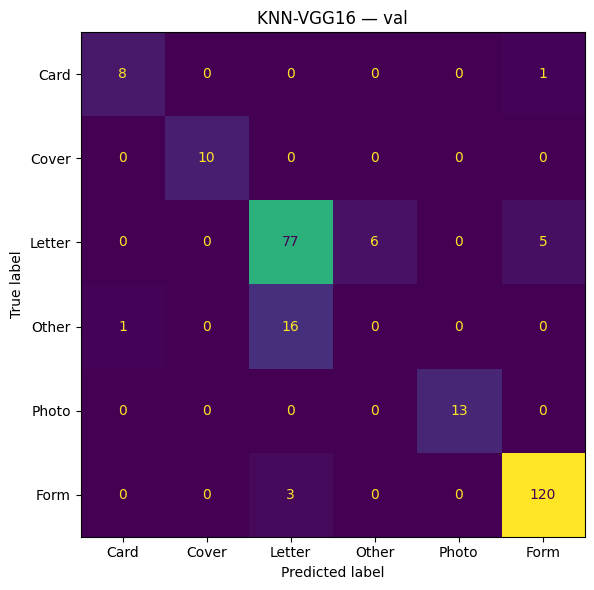


── KNN-VGG16 [test] ──
  Accuracy: 0.9076  |  Macro-F1: 0.8208
              precision    recall  f1-score   support

        Card       0.88      1.00      0.93         7
       Cover       1.00      1.00      1.00        10
      Letter       0.86      0.93      0.90        87
       Other       0.50      0.10      0.17        10
       Photo       1.00      1.00      1.00        24
        Form       0.93      0.93      0.93       100

    accuracy                           0.91       238
   macro avg       0.86      0.83      0.82       238
weighted avg       0.90      0.91      0.90       238



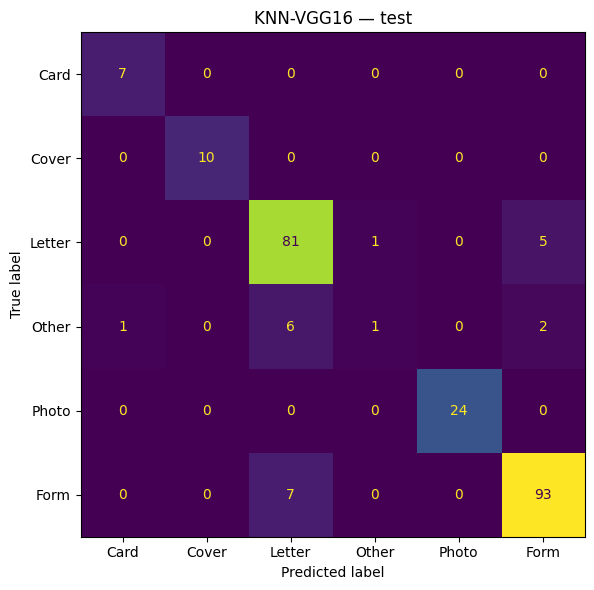

In [13]:
X_vgg_tr_n = normalize(X_vgg_tr)
X_vgg_va_n = normalize(X_vgg_va)
X_vgg_te_n = normalize(X_vgg_te)

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_vgg_tr_n, y_tr)
    f1 = f1_score(y_va, knn.predict(X_vgg_va_n), average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_vgg = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_vgg.fit(X_vgg_tr_n, y_tr)
pred_knn_vgg_te = knn_vgg.predict(X_vgg_te_n)

evaluate('KNN-VGG16', y_va, knn_vgg.predict(X_vgg_va_n), 'val')
results['KNN-VGG16'] = evaluate('KNN-VGG16', y_te, pred_knn_vgg_te, 'test')
results['KNN-VGG16']['preds_te'] = pred_knn_vgg_te

### 7b. XGBoost + VGG-16


── XGBoost-VGG16 [val] ──
  Accuracy: 0.8346  |  Macro-F1: 0.7431
              precision    recall  f1-score   support

        Card       1.00      0.67      0.80         9
       Cover       0.91      1.00      0.95        10
      Letter       0.71      0.90      0.79        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      1.00      1.00        13
        Form       0.94      0.89      0.91       123

    accuracy                           0.83       260
   macro avg       0.76      0.74      0.74       260
weighted avg       0.80      0.83      0.81       260



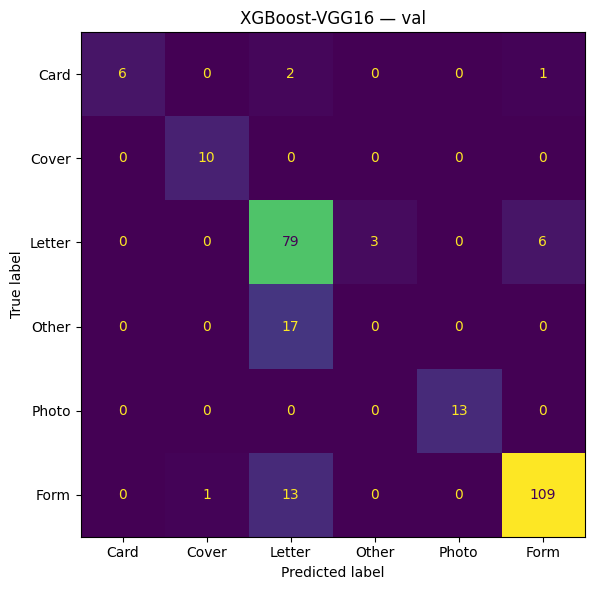


── XGBoost-VGG16 [test] ──
  Accuracy: 0.8992  |  Macro-F1: 0.7888
              precision    recall  f1-score   support

        Card       1.00      0.86      0.92         7
       Cover       1.00      1.00      1.00        10
      Letter       0.84      0.92      0.88        87
       Other       0.00      0.00      0.00        10
       Photo       1.00      1.00      1.00        24
        Form       0.92      0.94      0.93       100

    accuracy                           0.90       238
   macro avg       0.79      0.79      0.79       238
weighted avg       0.87      0.90      0.88       238



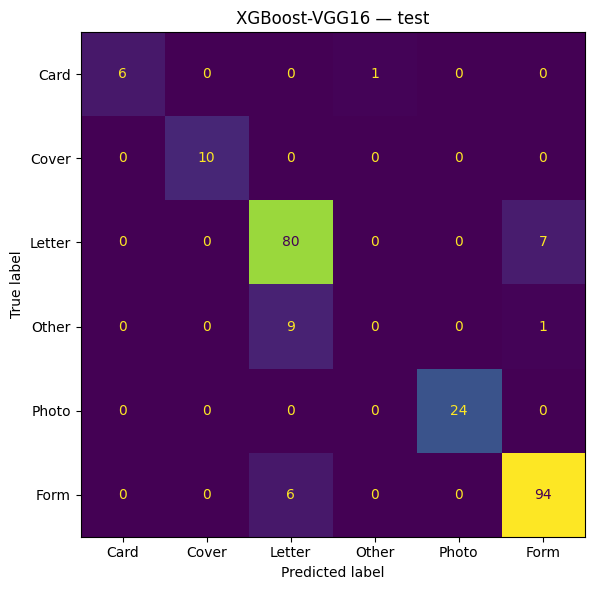

In [14]:
xgb_vgg = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_vgg.fit(X_vgg_tr, y_tr, eval_set=[(X_vgg_va, y_va)], verbose=False)
pred_xgb_vgg_te = xgb_vgg.predict(X_vgg_te)

evaluate('XGBoost-VGG16', y_va, xgb_vgg.predict(X_vgg_va), 'val')
results['XGBoost-VGG16'] = evaluate('XGBoost-VGG16', y_te, pred_xgb_vgg_te, 'test')
results['XGBoost-VGG16']['preds_te'] = pred_xgb_vgg_te

### 7c. VGG-16 Fine-Tuned (end-to-end)

VGG-16 fine-tune …
  Epoch  1  val_macro_f1=0.8037
  Epoch  2  val_macro_f1=0.8076
  Epoch  3  val_macro_f1=0.7747
  Epoch  4  val_macro_f1=0.8156
  Epoch  5  val_macro_f1=0.7986
  Epoch  6  val_macro_f1=0.7794
  Epoch  7  val_macro_f1=0.7847
  Epoch  8  val_macro_f1=0.7855
  Epoch  9  val_macro_f1=0.7698
  Epoch 10  val_macro_f1=0.7681
  Epoch 11  val_macro_f1=0.7810
  Epoch 12  val_macro_f1=0.7937
  Epoch 13  val_macro_f1=0.7939
  Epoch 14  val_macro_f1=0.7937
  Epoch 15  val_macro_f1=0.7917

── VGG-16 Fine-Tuned [test] ──
  Accuracy: 0.7521  |  Macro-F1: 0.7779
              precision    recall  f1-score   support

        Card       1.00      0.86      0.92         7
       Cover       1.00      1.00      1.00        10
      Letter       0.93      0.44      0.59        87
       Other       0.12      0.70      0.21        10
       Photo       1.00      1.00      1.00        24
        Form       0.95      0.94      0.94       100

    accuracy                           0.75      

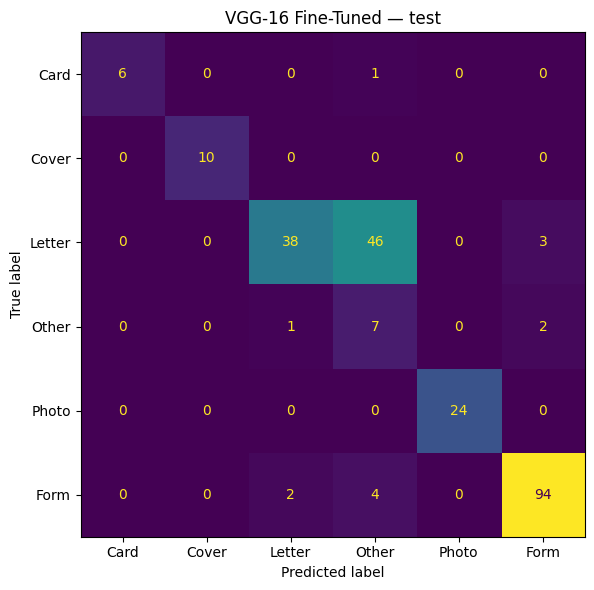

In [16]:
tr_img_loader, va_img_loader, te_img_loader = make_image_loaders(df_tr, df_va, df_te, batch=32)

vgg_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for p in vgg_ft.features.parameters():
    p.requires_grad = False
vgg_ft.classifier[6] = nn.Linear(4096, NUM_CLASSES)
vgg_ft = vgg_ft.to(DEVICE)

print('VGG-16 fine-tune …')
vgg_ft = train_finetune(vgg_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_vgg_ft_te, probs_vgg_ft = predict_image_model(vgg_ft, te_img_loader)
results['VGG16-FT'] = evaluate('VGG-16 Fine-Tuned', y_te, pred_vgg_ft_te, 'test')
results['VGG16-FT']['preds_te'] = pred_vgg_ft_te
results['VGG16-FT']['probs_te'] = probs_vgg_ft

### 7d. EfficientNet-B0 Fine-Tuned (end-to-end)

EfficientNet-B0 fine-tune …
  Epoch  1  val_macro_f1=0.5345
  Epoch  2  val_macro_f1=0.7295
  Epoch  3  val_macro_f1=0.7718
  Epoch  4  val_macro_f1=0.7736
  Epoch  5  val_macro_f1=0.7536
  Epoch  6  val_macro_f1=0.7703
  Epoch  7  val_macro_f1=0.7895
  Epoch  8  val_macro_f1=0.7864
  Epoch  9  val_macro_f1=0.7794
  Epoch 10  val_macro_f1=0.7799
  Epoch 11  val_macro_f1=0.7858
  Epoch 12  val_macro_f1=0.7913
  Epoch 13  val_macro_f1=0.8015
  Epoch 14  val_macro_f1=0.7954
  Epoch 15  val_macro_f1=0.7937

── EfficientNet-B0 Fine-Tuned [test] ──
  Accuracy: 0.8193  |  Macro-F1: 0.7903
              precision    recall  f1-score   support

        Card       0.88      1.00      0.93         7
       Cover       1.00      1.00      1.00        10
      Letter       0.79      0.82      0.80        87
       Other       0.18      0.20      0.19        10
       Photo       1.00      0.96      0.98        24
        Form       0.85      0.82      0.84       100

    accuracy                   

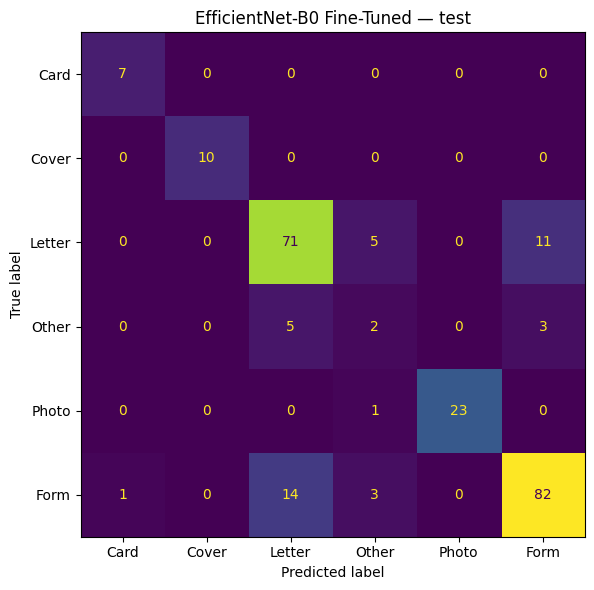

In [17]:
eff_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for p in eff_ft.features.parameters():
    p.requires_grad = False
in_features = eff_ft.classifier[1].in_features
eff_ft.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES),
)
eff_ft = eff_ft.to(DEVICE)

print('EfficientNet-B0 fine-tune …')
eff_ft = train_finetune(eff_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_eff_ft_te, probs_eff_ft = predict_image_model(eff_ft, te_img_loader)
results['EfficientNet-FT'] = evaluate('EfficientNet-B0 Fine-Tuned', y_te, pred_eff_ft_te, 'test')
results['EfficientNet-FT']['preds_te'] = pred_eff_ft_te
results['EfficientNet-FT']['probs_te'] = probs_eff_ft

### 7e. LSTM + VGG-16

Each dossier is treated as a **sequence of start pages** ordered by page number.  
A bidirectional LSTM reads the 4096-D VGG-16 feature at each start-page position  
and predicts the layout type at every position.

In [18]:
class DossierSequenceDataset(Dataset):
    """Groups start pages by dossier into variable-length sequences."""
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for _, grp in df.groupby('dossier'):
            idx   = grp.index.tolist()
            feats = X_feat[idx]
            lbls  = df.loc[idx, 'label'].values
            self.sequences.append((
                torch.tensor(feats, dtype=torch.float32),
                torch.tensor(lbls,  dtype=torch.long),
            ))

    def __len__(self): return len(self.sequences)
    def __getitem__(self, i): return self.sequences[i]


def collate_sequences(batch):
    feats, lbls = zip(*batch)
    lengths   = torch.tensor([f.shape[0] for f in feats], dtype=torch.long)
    feats_pad = nn.utils.rnn.pad_sequence(feats, batch_first=True)
    lbls_pad  = nn.utils.rnn.pad_sequence(lbls,  batch_first=True, padding_value=-1)
    return feats_pad, lbls_pad, lengths


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2,
                 dropout=0.3, n_classes=NUM_CLASSES):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        x = self.proj(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.head(out)


lstm_tr_ds = DossierSequenceDataset(df_tr, X_vgg)
lstm_va_ds = DossierSequenceDataset(df_va, X_vgg)
lstm_te_ds = DossierSequenceDataset(df_te, X_vgg)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=collate_sequences)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=collate_sequences)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=collate_sequences)

lstm_model = LSTMClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw, ignore_index=-1)
opt  = optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    lstm_model.train()
    for feats, lbls, lengths in lstm_tr_loader:
        feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
        opt.zero_grad()
        loss = crit(lstm_model(feats, lengths).view(-1, NUM_CLASSES), lbls.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        opt.step()
    sch.step()

    lstm_model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for feats, lbls, lengths in lstm_va_loader:
            preds = lstm_model(feats.to(DEVICE), lengths).argmax(-1).cpu().numpy()
            truth = lbls.numpy()
            mask  = truth != -1
            all_true.extend(truth[mask].tolist())
            all_pred.extend(preds[mask].tolist())
    f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_state)
print(f'Best val macro-F1: {best_f1:.4f}')

  Epoch  1  val_macro_f1=0.5645
  Epoch  2  val_macro_f1=0.7707
  Epoch  3  val_macro_f1=0.7427
  Epoch  4  val_macro_f1=0.7260
  Epoch  5  val_macro_f1=0.7605
  Epoch  6  val_macro_f1=0.7586
  Epoch  7  val_macro_f1=0.7700
  Epoch  8  val_macro_f1=0.7996
  Epoch  9  val_macro_f1=0.7778
  Epoch 10  val_macro_f1=0.8162
  Epoch 11  val_macro_f1=0.7688
  Epoch 12  val_macro_f1=0.7848
  Epoch 13  val_macro_f1=0.7798
  Epoch 14  val_macro_f1=0.7876
  Epoch 15  val_macro_f1=0.7979
  Epoch 16  val_macro_f1=0.7975
  Epoch 17  val_macro_f1=0.7862
  Epoch 18  val_macro_f1=0.7900
  Epoch 19  val_macro_f1=0.7921
  Epoch 20  val_macro_f1=0.7899
Best val macro-F1: 0.8162



── LSTM + VGG-16 [test] ──
  Accuracy: 0.7983  |  Macro-F1: 0.7269
              precision    recall  f1-score   support

        Card       0.50      1.00      0.67         7
       Cover       1.00      1.00      1.00        10
      Letter       0.88      0.61      0.72        87
       Other       0.05      0.10      0.06        10
       Photo       1.00      1.00      1.00        24
        Form       0.87      0.95      0.91       100

    accuracy                           0.80       238
   macro avg       0.72      0.78      0.73       238
weighted avg       0.85      0.80      0.81       238



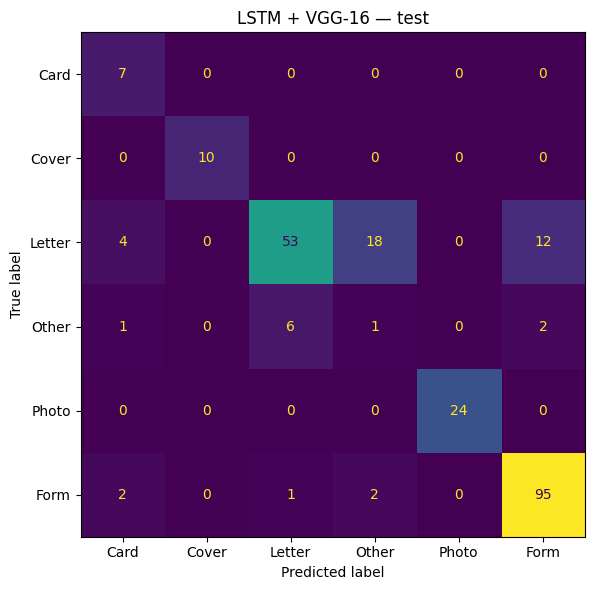

In [19]:
lstm_model.eval()
all_true_lstm, all_pred_lstm = [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        logits = lstm_model(feats.to(DEVICE), lengths)
        preds  = logits.argmax(-1).cpu().numpy()
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds[mask].tolist())

results['LSTM-VGG16'] = evaluate(
    'LSTM + VGG-16', np.array(all_true_lstm), np.array(all_pred_lstm), 'test')
results['LSTM-VGG16']['preds_te'] = np.array(all_pred_lstm)

---
## 8. Text-Only Models

### 8a. KNN + BERT


── KNN-BERT [val] ──
  Accuracy: 0.8769  |  Macro-F1: 0.7386
              precision    recall  f1-score   support

        Card       0.75      0.67      0.71         9
       Cover       1.00      1.00      1.00        10
      Letter       0.81      0.94      0.87        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      0.85      0.92        13
        Form       0.92      0.96      0.94       123

    accuracy                           0.88       260
   macro avg       0.75      0.74      0.74       260
weighted avg       0.82      0.88      0.85       260



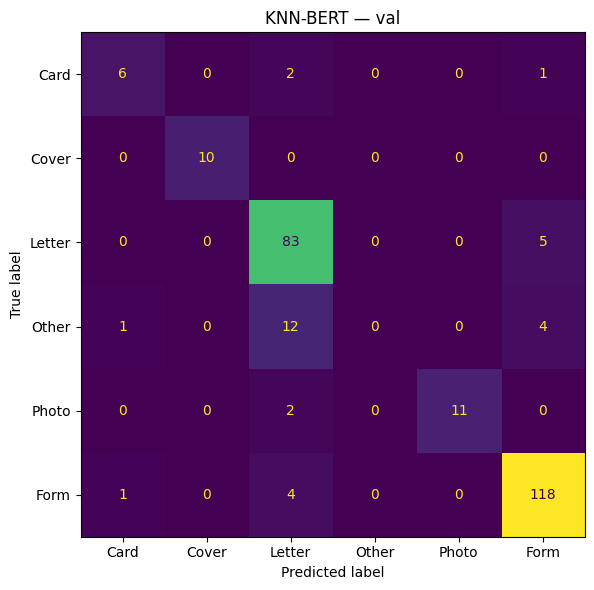


── KNN-BERT [test] ──
  Accuracy: 0.8824  |  Macro-F1: 0.7201
              precision    recall  f1-score   support

        Card       0.62      0.71      0.67         7
       Cover       1.00      1.00      1.00        10
      Letter       0.78      0.95      0.86        87
       Other       0.00      0.00      0.00        10
       Photo       1.00      0.71      0.83        24
        Form       0.98      0.95      0.96       100

    accuracy                           0.88       238
   macro avg       0.73      0.72      0.72       238
weighted avg       0.86      0.88      0.86       238



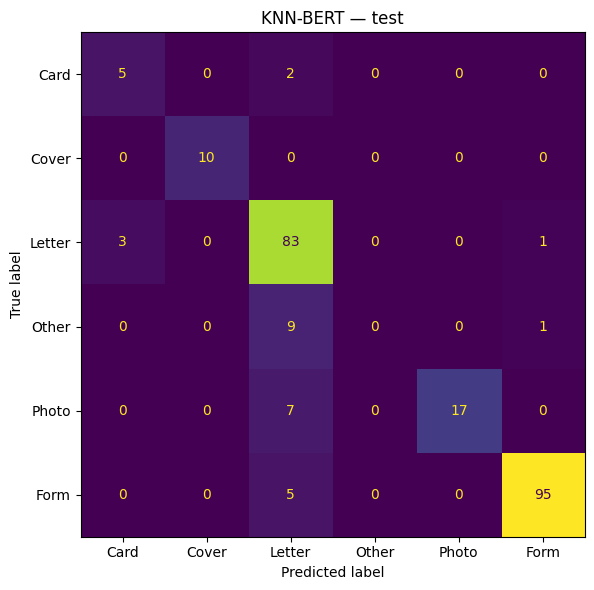

In [20]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

knn_bert = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)

pred_knn_bert_te = knn_bert.predict(X_bert_te_n)
evaluate('KNN-BERT', y_va, knn_bert.predict(X_bert_va_n), 'val')
results['KNN-BERT'] = evaluate('KNN-BERT', y_te, pred_knn_bert_te, 'test')
results['KNN-BERT']['preds_te'] = pred_knn_bert_te

### 8b. XGBoost + BERT


── XGBoost-BERT [val] ──
  Accuracy: 0.8500  |  Macro-F1: 0.6927
              precision    recall  f1-score   support

        Card       1.00      0.33      0.50         9
       Cover       1.00      0.90      0.95        10
      Letter       0.75      0.91      0.82        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      0.92      0.96        13
        Form       0.91      0.95      0.93       123

    accuracy                           0.85       260
   macro avg       0.78      0.67      0.69       260
weighted avg       0.81      0.85      0.82       260



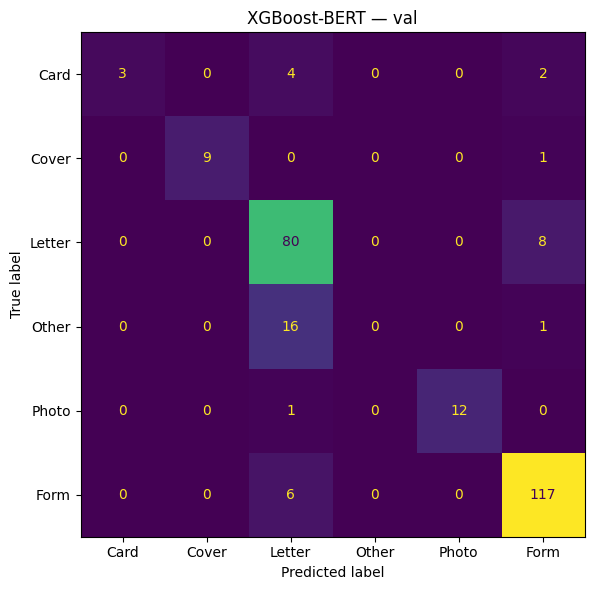


── XGBoost-BERT [test] ──
  Accuracy: 0.8824  |  Macro-F1: 0.7593
              precision    recall  f1-score   support

        Card       1.00      0.71      0.83         7
       Cover       1.00      1.00      1.00        10
      Letter       0.80      0.93      0.86        87
       Other       0.00      0.00      0.00        10
       Photo       0.96      0.92      0.94        24
        Form       0.93      0.92      0.92       100

    accuracy                           0.88       238
   macro avg       0.78      0.75      0.76       238
weighted avg       0.85      0.88      0.86       238



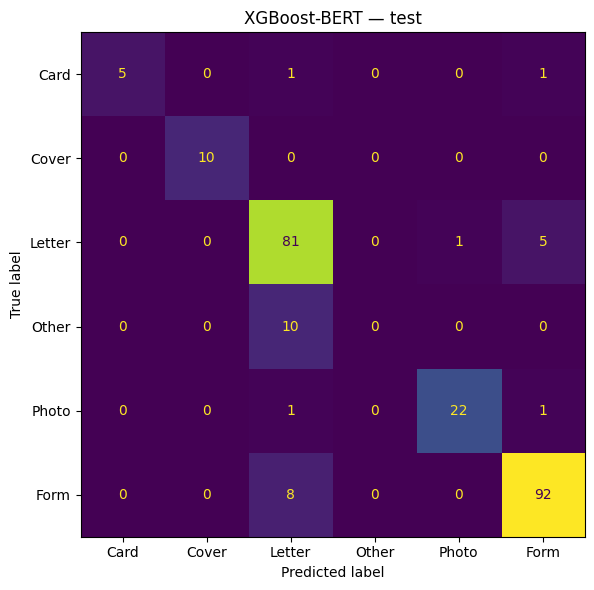

In [21]:
xgb_bert = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_bert.fit(X_bert_tr, y_tr, eval_set=[(X_bert_va, y_va)], verbose=False)
pred_xgb_bert_te = xgb_bert.predict(X_bert_te)

evaluate('XGBoost-BERT', y_va, xgb_bert.predict(X_bert_va), 'val')
results['XGBoost-BERT'] = evaluate('XGBoost-BERT', y_te, pred_xgb_bert_te, 'test')
results['XGBoost-BERT']['preds_te'] = pred_xgb_bert_te

### 8c. TEXT-CNN (frozen BERT backbone + 1D-CNN)

Frozen BERT token embeddings → multi-scale 1D convolutions → max-over-time pooling → linear head.

In [22]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool → MLP."""
    def __init__(self, bert_model, embed_dim=768, num_filters=128,
                 filter_sizes=(2, 3, 4), num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.bert  = bert_model
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb = out.last_hidden_state    # (B, T, E)
        x = emb.transpose(1, 2)            # (B, E, T)
        pooled = [
            F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
            for conv in self.convs
        ]
        return self.fc(self.drop(torch.cat(pooled, dim=1)))


tcnn_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_loader = DataLoader(TextDataset(df_tr, tcnn_tokenizer), batch_size=16, shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(TextDataset(df_va, tcnn_tokenizer), batch_size=16, shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(TextDataset(df_te, tcnn_tokenizer), batch_size=16, shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)
print(f'TEXT-CNN trainable params: {sum(p.numel() for p in tcnn_model.parameters() if p.requires_grad):,}')

TEXT-CNN trainable params: 887,430


Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.7251
  Epoch  2  val_macro_f1=0.7836
  Epoch  3  val_macro_f1=0.7448
  Epoch  4  val_macro_f1=0.7569
  Epoch  5  val_macro_f1=0.7694
  Epoch  6  val_macro_f1=0.7910
  Epoch  7  val_macro_f1=0.7534
  Epoch  8  val_macro_f1=0.7785
  Epoch  9  val_macro_f1=0.7710
  Epoch 10  val_macro_f1=0.8039
  Epoch 11  val_macro_f1=0.7502
  Epoch 12  val_macro_f1=0.7445
  Epoch 13  val_macro_f1=0.7468
  Epoch 14  val_macro_f1=0.7497
  Epoch 15  val_macro_f1=0.7675

── TEXT-CNN [test] ──
  Accuracy: 0.8697  |  Macro-F1: 0.7534
              precision    recall  f1-score   support

        Card       0.75      0.86      0.80         7
       Cover       1.00      1.00      1.00        10
      Letter       0.88      0.83      0.85        87
       Other       0.00      0.00      0.00        10
       Photo       0.86      1.00      0.92        24
        Form       0.94      0.95      0.95       100

    accuracy                           0.87       238
   

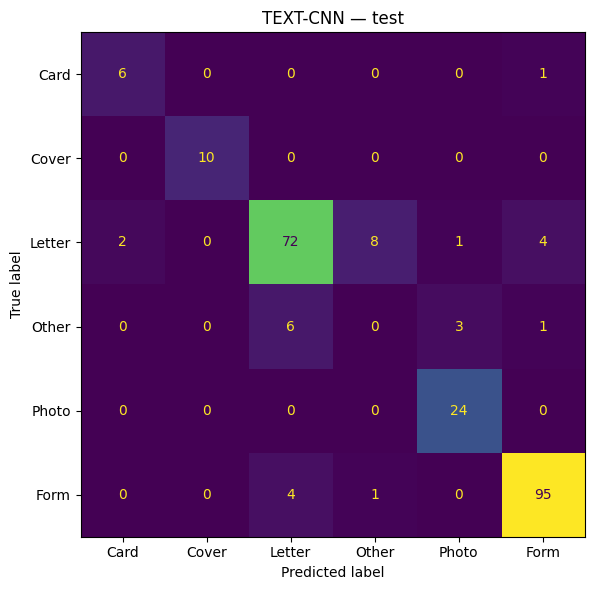

In [23]:
def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(ids, mask), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader, n_epochs=15)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)
results['TEXT-CNN'] = evaluate('TEXT-CNN', y_te, pred_tcnn_te, 'test')
results['TEXT-CNN']['preds_te'] = pred_tcnn_te
results['TEXT-CNN']['probs_te'] = probs_tcnn

### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,486,854
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.7912
  Epoch  2  val_macro_f1=0.7368
  Epoch  3  val_macro_f1=0.7657
  Epoch  4  val_macro_f1=0.7464
  Epoch  5  val_macro_f1=0.7517
  Epoch  6  val_macro_f1=0.7411
  Epoch  7  val_macro_f1=0.7805
  Epoch  8  val_macro_f1=0.7636
  Epoch  9  val_macro_f1=0.7583
  Epoch 10  val_macro_f1=0.7389

── BERT Fine-Tuned [test] ──
  Accuracy: 0.8403  |  Macro-F1: 0.7775
              precision    recall  f1-score   support

        Card       1.00      0.71      0.83         7
       Cover       1.00      1.00      1.00        10
      Letter       0.85      0.76      0.80        87
       Other       0.08      0.20      0.12        10
       Photo       0.92      1.00      0.96        24
        Form       0.98      0.93      0.95       100

    accuracy                           0.84       238
   macro avg       0.81      0.77      0.78       238
weighted avg       0.89      0.84      0.86       238


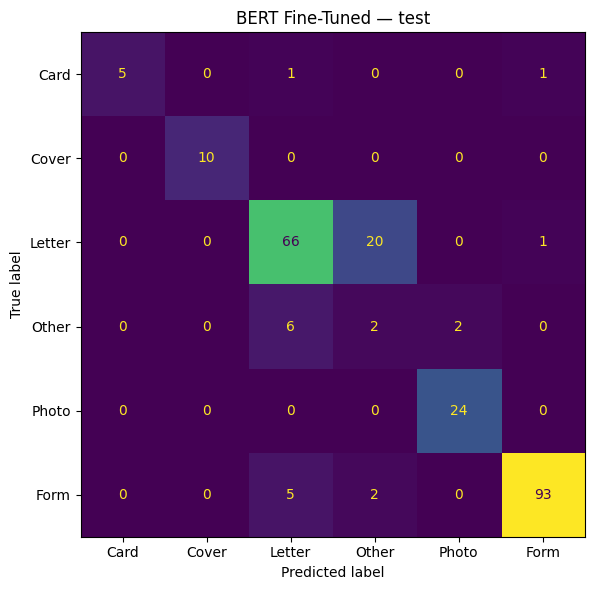

In [24]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_loader = DataLoader(TextDataset(df_tr, bert_ft_tokenizer), batch_size=8,  shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(TextDataset(df_va, bert_ft_tokenizer), batch_size=16, shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(TextDataset(df_te, bert_ft_tokenizer), batch_size=16, shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)

pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
results['BERT-FT'] = evaluate('BERT Fine-Tuned', y_te, pred_bert_ft_te, 'test')
results['BERT-FT']['preds_te'] = pred_bert_ft_te
results['BERT-FT']['probs_te'] = probs_bert_ft

---
## 9. Multimodal / Fusion Models

### 9a. KNN-Ensemble (VGG-16 + BERT concatenated features)

L2-normalised VGG-16 (4096-D) and BERT (768-D) features concatenated → 4864-D vector.


── KNN-Ensemble [val] ──
  Accuracy: 0.8923  |  Macro-F1: 0.7726
              precision    recall  f1-score   support

        Card       0.80      0.89      0.84         9
       Cover       1.00      1.00      1.00        10
      Letter       0.81      0.94      0.87        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      0.92      0.96        13
        Form       0.95      0.97      0.96       123

    accuracy                           0.89       260
   macro avg       0.76      0.79      0.77       260
weighted avg       0.84      0.89      0.87       260



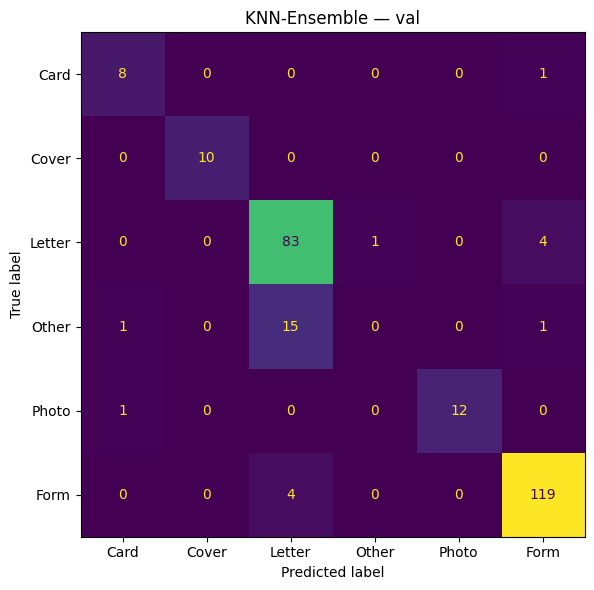


── KNN-Ensemble [test] ──
  Accuracy: 0.9160  |  Macro-F1: 0.8261
              precision    recall  f1-score   support

        Card       0.88      1.00      0.93         7
       Cover       1.00      1.00      1.00        10
      Letter       0.86      0.95      0.90        87
       Other       1.00      0.10      0.18        10
       Photo       1.00      1.00      1.00        24
        Form       0.95      0.93      0.94       100

    accuracy                           0.92       238
   macro avg       0.95      0.83      0.83       238
weighted avg       0.92      0.92      0.90       238



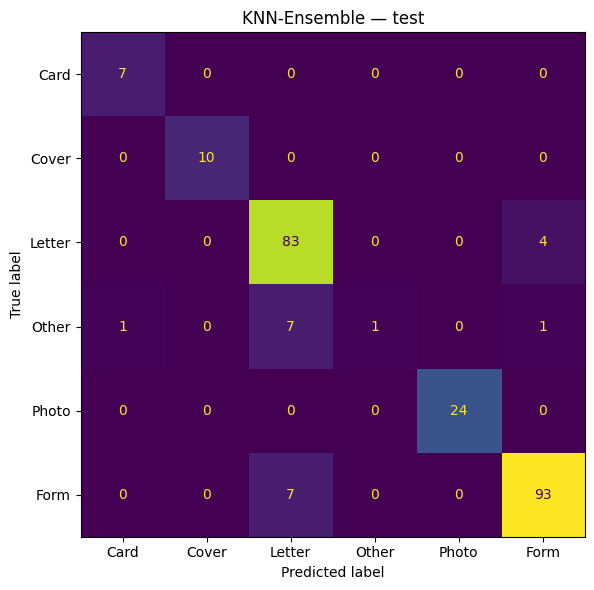

In [25]:
X_ens_tr = np.hstack([normalize(X_vgg_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_vgg_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_vgg_te), normalize(X_bert_te)])

knn_ens = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)

pred_knn_ens_te = knn_ens.predict(X_ens_te)
evaluate('KNN-Ensemble', y_va, knn_ens.predict(X_ens_va), 'val')
results['KNN-Ensemble'] = evaluate('KNN-Ensemble', y_te, pred_knn_ens_te, 'test')
results['KNN-Ensemble']['preds_te'] = pred_knn_ens_te

### 9b. XGBoost-Ensemble (VGG-16 + BERT concatenated features)


── XGBoost-Ensemble [val] ──
  Accuracy: 0.8615  |  Macro-F1: 0.7452
              precision    recall  f1-score   support

        Card       1.00      0.56      0.71         9
       Cover       1.00      1.00      1.00        10
      Letter       0.76      0.89      0.82        88
       Other       0.00      0.00      0.00        17
       Photo       1.00      1.00      1.00        13
        Form       0.92      0.96      0.94       123

    accuracy                           0.86       260
   macro avg       0.78      0.73      0.75       260
weighted avg       0.82      0.86      0.83       260



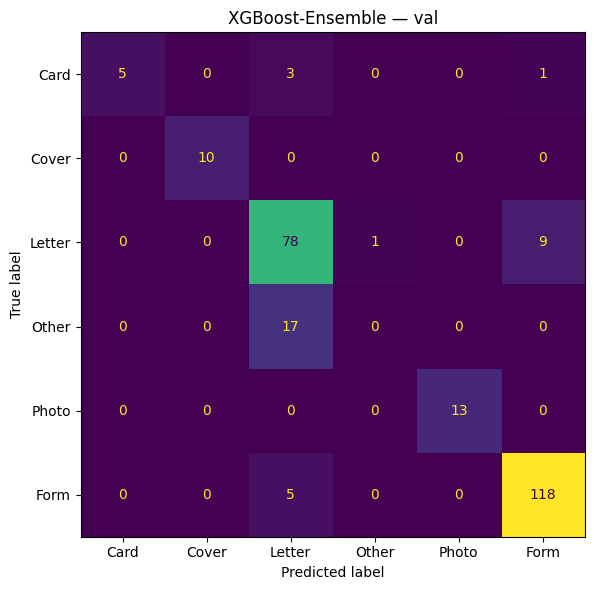


── XGBoost-Ensemble [test] ──
  Accuracy: 0.9202  |  Macro-F1: 0.7952
              precision    recall  f1-score   support

        Card       1.00      0.86      0.92         7
       Cover       1.00      1.00      1.00        10
      Letter       0.86      0.98      0.91        87
       Other       0.00      0.00      0.00        10
       Photo       0.96      1.00      0.98        24
        Form       0.97      0.94      0.95       100

    accuracy                           0.92       238
   macro avg       0.80      0.80      0.80       238
weighted avg       0.89      0.92      0.90       238



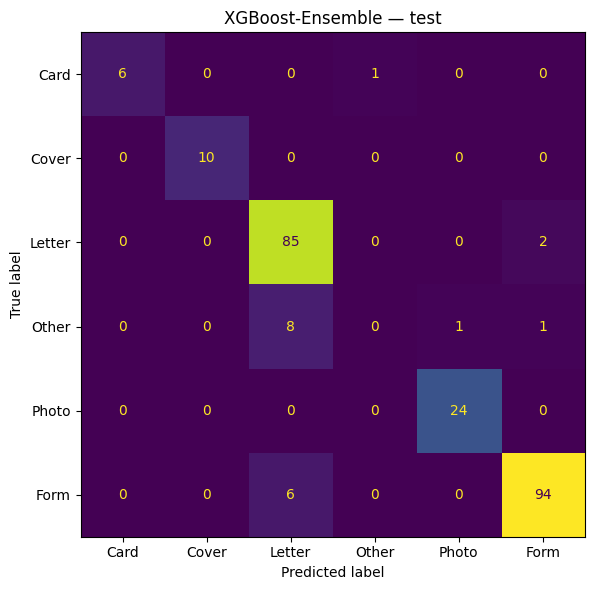

In [26]:
xgb_ens = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_ens.fit(X_ens_tr, y_tr, eval_set=[(X_ens_va, y_va)], verbose=False)
pred_xgb_ens_te = xgb_ens.predict(X_ens_te)

evaluate('XGBoost-Ensemble', y_va, xgb_ens.predict(X_ens_va), 'val')
results['XGBoost-Ensemble'] = evaluate('XGBoost-Ensemble', y_te, pred_xgb_ens_te, 'test')
results['XGBoost-Ensemble']['preds_te'] = pred_xgb_ens_te

### 9c. Early Fusion — EfficientNet-B0 + BERT → MLP

Frozen EfficientNet-B0 (1280-D) and frozen BERT [CLS] (768-D) features are **projected independently**  
then **concatenated** before a shared MLP head is trained from scratch.

  Epoch  1  val_macro_f1=0.8301
  Epoch  2  val_macro_f1=0.7630
  Epoch  3  val_macro_f1=0.8583
  Epoch  4  val_macro_f1=0.8440
  Epoch  5  val_macro_f1=0.8219
  Epoch  6  val_macro_f1=0.8232
  Epoch  7  val_macro_f1=0.8197
  Epoch  8  val_macro_f1=0.8269
  Epoch  9  val_macro_f1=0.8434
  Epoch 10  val_macro_f1=0.8141
  Epoch 11  val_macro_f1=0.8258
  Epoch 12  val_macro_f1=0.8150
  Epoch 13  val_macro_f1=0.8069
  Epoch 14  val_macro_f1=0.8015
  Epoch 15  val_macro_f1=0.8012
  Epoch 16  val_macro_f1=0.8021
  Epoch 17  val_macro_f1=0.8100
  Epoch 18  val_macro_f1=0.8061
  Epoch 19  val_macro_f1=0.8096
  Epoch 20  val_macro_f1=0.8067

── Early Fusion EfficientNet+BERT [test] ──
  Accuracy: 0.8277  |  Macro-F1: 0.7920
              precision    recall  f1-score   support

        Card       1.00      0.86      0.92         7
       Cover       1.00      1.00      1.00        10
      Letter       0.82      0.72      0.77        87
       Other       0.07      0.20      0.10        10
    

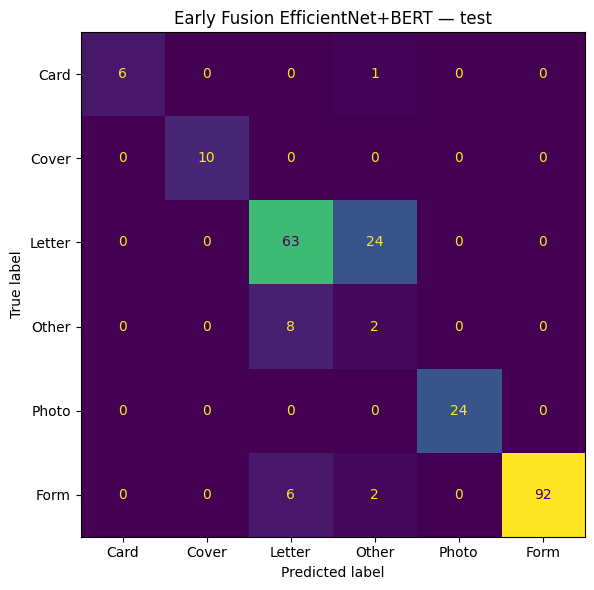

In [27]:
class EarlyFusionDataset(Dataset):
    def __init__(self, img_feats: np.ndarray, text_feats: np.ndarray, labels: np.ndarray):
        self.img    = torch.tensor(img_feats,  dtype=torch.float32)
        self.text   = torch.tensor(text_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.img[i], self.text[i], self.labels[i]


class EarlyFusionClassifier(nn.Module):
    def __init__(self, img_dim=1280, text_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim,  hidden)
        self.text_proj = nn.Linear(text_dim, hidden)
        self.head = nn.Sequential(
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, img_feat, text_feat):
        return self.head(torch.cat([
            self.img_proj(img_feat), self.text_proj(text_feat),
        ], dim=1))


ef_tr_loader = DataLoader(
    EarlyFusionDataset(X_eff_tr, X_bert_tr, y_tr), batch_size=32, shuffle=True)
ef_va_loader = DataLoader(
    EarlyFusionDataset(X_eff_va, X_bert_va, y_va), batch_size=32, shuffle=False)
ef_te_loader = DataLoader(
    EarlyFusionDataset(X_eff_te, X_bert_te, y_te), batch_size=32, shuffle=False)

ef_model = EarlyFusionClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam(ef_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    ef_model.train()
    for img_f, txt_f, yb in ef_tr_loader:
        img_f, txt_f, yb = img_f.to(DEVICE), txt_f.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(img_f, txt_f), yb).backward()
        opt.step()
    sch.step()

    ef_model.eval()
    preds = []
    with torch.no_grad():
        for img_f, txt_f, _ in ef_va_loader:
            preds.extend(ef_model(img_f.to(DEVICE), txt_f.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)
ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for img_f, txt_f, _ in ef_te_loader:
        logits = ef_model(img_f.to(DEVICE), txt_f.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())

pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)
results['EarlyFusion'] = evaluate('Early Fusion EfficientNet+BERT', y_te, pred_ef_te, 'test')
results['EarlyFusion']['preds_te'] = pred_ef_te
results['EarlyFusion']['probs_te'] = probs_ef

### 9d. Late Fusion — EfficientNet-B0 FT + BERT FT (average softmax)

The softmax probability vectors from the individually trained `EfficientNet-FT` and `BERT-FT` models  
are **averaged** to produce the final prediction.


── Late Fusion EfficientNet+BERT [test] ──
  Accuracy: 0.8613  |  Macro-F1: 0.7865
              precision    recall  f1-score   support

        Card       1.00      0.71      0.83         7
       Cover       1.00      1.00      1.00        10
      Letter       0.85      0.80      0.83        87
       Other       0.11      0.20      0.14        10
       Photo       0.92      1.00      0.96        24
        Form       0.98      0.94      0.96       100

    accuracy                           0.86       238
   macro avg       0.81      0.78      0.79       238
weighted avg       0.89      0.86      0.87       238



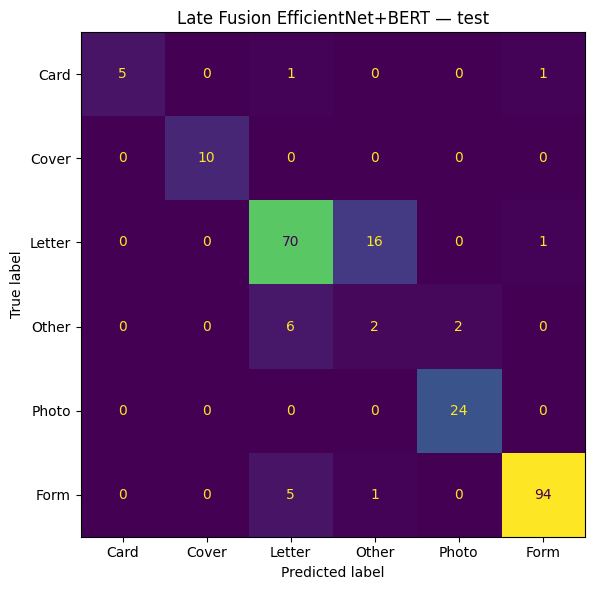

In [28]:
probs_eff_arr  = results['EfficientNet-FT']['probs_te']   # (N_te, 6)
probs_bert_arr = results['BERT-FT']['probs_te']           # (N_te, 6)

probs_late = (probs_eff_arr + probs_bert_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

results['LateFusion'] = evaluate('Late Fusion EfficientNet+BERT', y_te, pred_late, 'test')
results['LateFusion']['preds_te'] = pred_late
results['LateFusion']['probs_te'] = probs_late

## 10. Summary

In [29]:
summary_df = (
    pd.DataFrame({name: {'accuracy': v['accuracy'], 'macro_f1': v['macro_f1']}
                  for name, v in results.items()}).T
      .round(4)
)
summary_df.index.name = 'Model'
print(summary_df.to_string())
summary_df

                  accuracy  macro_f1
Model                               
KNN-VGG16           0.9076    0.8208
XGBoost-VGG16       0.8992    0.7888
VGG16-FT            0.7521    0.7779
EfficientNet-FT     0.8193    0.7903
LSTM-VGG16          0.7983    0.7269
KNN-BERT            0.8824    0.7201
XGBoost-BERT        0.8824    0.7593
TEXT-CNN            0.8697    0.7534
BERT-FT             0.8403    0.7775
KNN-Ensemble        0.9160    0.8261
XGBoost-Ensemble    0.9202    0.7952
EarlyFusion         0.8277    0.7920
LateFusion          0.8613    0.7865


,accuracy,macro_f1
Model,,
KNN-VGG16,0.9076,0.8208
XGBoost-VGG16,0.8992,0.7888
VGG16-FT,0.7521,0.7779
EfficientNet-FT,0.8193,0.7903
LSTM-VGG16,0.7983,0.7269
KNN-BERT,0.8824,0.7201
XGBoost-BERT,0.8824,0.7593
TEXT-CNN,0.8697,0.7534
BERT-FT,0.8403,0.7775


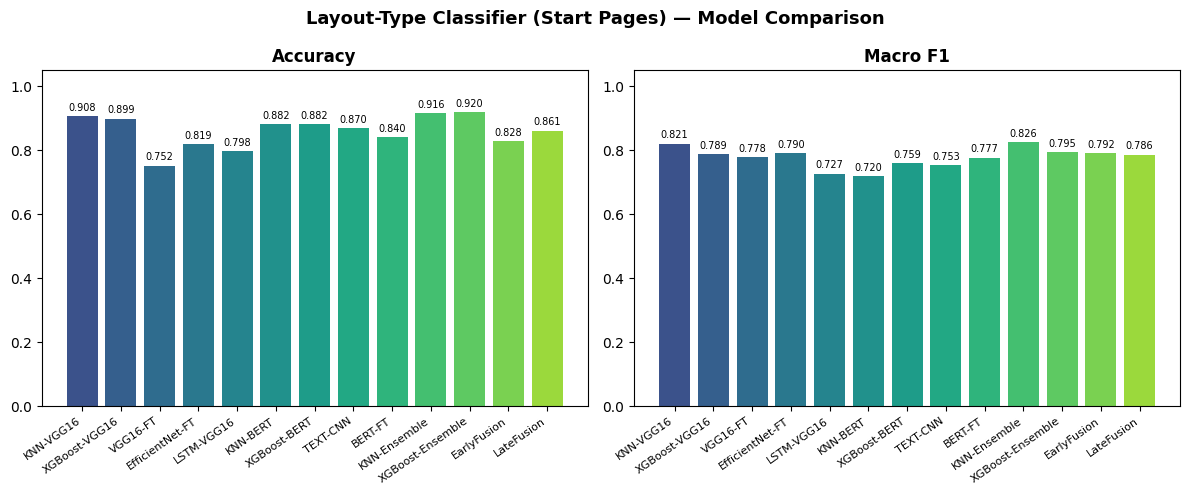

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['accuracy', 'macro_f1']):
    vals   = summary_df[metric].astype(float)
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(vals)))
    bars   = ax.bar(vals.index, vals.values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Layout-Type Classifier (Start Pages) — Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()